# hyperparameters tuning
### No of hidden layers
### Batch size
### learning rate
### Epoch size
### No of neurons per layer
### Optimizer
### Activation Function


### so no of hidden layers should be more instead of one large single layer because using multiple hidden layers helps in recognizing the images or inputs better and like the initial layers captures the lines and face structures the edges and corners and suppose we have trained a NN model to recognize human faces and then in another project you have to develop a NN model to recogize monkey faces so as we all know monkeys and humans have much similarity according to the face structure right so we will grab the initial layers from the already trained model we just built for the humans and use them for monkey recognition model this technique is called as TRANSFER LEARNING and is important concept in deep learning

### Adding more data
### Reducing the complexity of the NN
### Regularization (L1 , L2)
### Dropouts
### Data Augmentation
### Batch Normalization
### Early Stoping


In [ ]:
#  Warming up the learning rate


## Warming up the learning rate
### so we know there are three techniques for split out data and calc GD: GD of Batch_size
### 1. batch gradient descent : after entire batch the weights will be updated
### 2. stocastic Gradient Descent : after every row the weights will be updated
### 3. Mini batch GD : two approaches
### 1. small batch. take (8 to 32)
### 2. Larger batch. take ( 8192 ): depends on GPU RAM up to you
### now the difference is in small batch the training is slow but learns so well but in the large size batch training time will be less and engineers worked on the large batch size approach and like discovered the technique of warming up the learning rate in which:
### in the initial epoches learning rate will be very very small and the with the increasing epochs the learning rate will also increase that way the model will learn faster and the results will also be better as well...

# Vanishing and Vanishing exploding gradients
### weight init
### Activation function
### Batch Norm
### Grad Cipping

# Not enough data
### Transfer learning
### Unsupervised pretra

# Slow training Adam
### Optimizers
### learning rate Scheduler


# Overfitting
### L1, and 12
### Dropouts

#

#DROPOUTS IN NN

# Dropout is a highly effective regularization technique in deep learning where a random fraction of neurons are temporarily "dropped out" (disabled) during the training phase
# Dropouts is the new concept in the deeplearning in which we like
# drop the internal neurons from input layer and hidden layer randomly becasue this was we can minimize the complexity of our Neural network and another benefit is think like in first epoch you drop a neuron randomly which minimized the complexity of NN plus it will help the NN to not rutt the NN rather it will learn the NN  

# Breaks Co-adaptation: When networks train without dropout, some neurons might rely on their neighbors to compensate for errors. This creates a dangerous dependency. Dropout forces every single neuron to learn useful, independent features

# Acts as an Implicit Ensemble: Every time you drop a different set of neurons, you are effectively training a slightly different, smaller network. Over many epochs, your model learns from thousands of these variations, making the final network incredibly robust when it sees new data

# Prevents Memorization (Overfitting): By constantly changing the active pathways, the network is unable to just "memorize" the training data. It is forced to learn the actual, underlying patterns

# Note for Testing/Inference: Dropout is only applied during training. During the testing or prediction phase, all neurons are active, but their outputs are scaled down by the dropout rate to balance out the network's behavior

# DORPOUTS can affect your model by 2% and its not a small increment its a huge improvement for your model so remember to apply dropouts technique onto your model

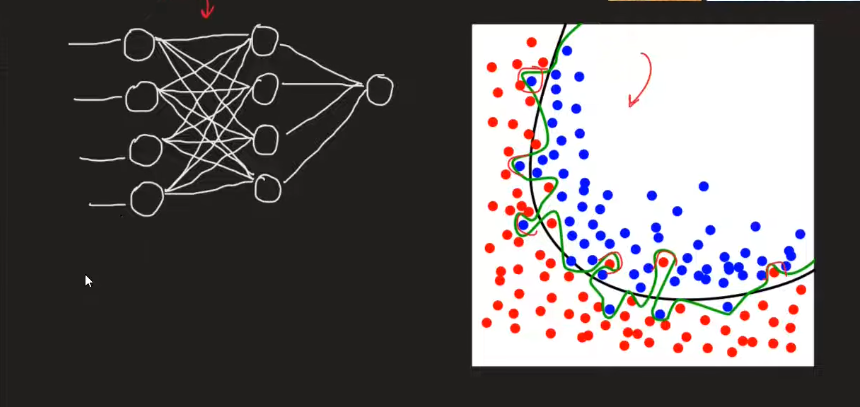

## this pic here shows the overfitting of a model like see the model is trying to capture every single small/tiny details of a model Network tries to capture every single and every small pattern which leads to
# overfitting
## so how to reduce the OVERFITTING then:

# Reduce the number of NODES : this make the model unable to focus to tiny details and patterns which we do not want we can say focusing on that tiny details could be unwanted...

# In this technique : we have to make our model not to focus on the very small details and patterns rather it should focus on the whole patterns so our main motive is to make sure our model should not focus on the single details and tiny details...


## and this what dropouts do


## and in testing all nodes will be present not any dropouts

## task:
## learn how probability works under the hood in dropouts like w(1 - p) in training if i want to make a node present suppose there were four nodes in a single layer and i said dropout probab = 0.25 which means 1 - p will be present probability for this example 1 - 0.25 = 0.75 and there will be 0.75 probability to be present for a node

In [ ]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(device)

cuda


In [ ]:
df = pd.read_csv("/content/fashion-mnist_train.csv")

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

In [ ]:
X = df.iloc[:,1:].values
y = df.iloc[: , 0].values

In [ ]:
X_train , x_test , y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [ ]:
X_train = X_train/255.0
x_test = x_test/255.0

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
class DeclareDataSet(Dataset):
    def __init__(self, n_features , labels):
      self.n_features = torch.tensor(n_features , dtype=torch.float32)
      self.labels = torch.tensor(labels , dtype=torch.long)

    def __len__(self):
      return len(self.n_features)

    def __getitem__(self, index):
      return self.n_features[index] , self.labels[index]


In [ ]:
train_dataset = DeclareDataSet(X_train , y_train)
test_dataset = DeclareDataSet(x_test , y_test)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
class neural_network(nn.Module):
  def __init__(self , n_features):
    super().__init__()

    self.module = nn.Sequential(
        nn.Linear(n_features, 128),
        nn.BatchNorm1d(128),   # normalization apply: before activation and after the hidden layer
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64, 10)

    )

  def forward(self, X):
    return self.module(X)



In [ ]:
model = neural_network(X_train.shape[1])

In [ ]:
model.to(device)

neural_network(
  (module): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
learning_rate = 0.1
epoches = 30

In [ ]:
lossed = nn.CrossEntropyLoss()

### L2 regularization here lamda(weight decay = 10^-4 regularization coefficient

In [ ]:
optimizer = optim.SGD(model.parameters() , lr=learning_rate, weight_decay=1e-4)

In [ ]:
for epoch in range(epoches):

  total_loss_epoch = 0

  for batch_features , batch_labels in train_dataloader:


    # move to GPU
    batch_features , batch_labels = batch_features.to(device) , batch_labels.to(device)

    # call forward pass
    outputs = model(batch_features)

    # calc loss

    loss = lossed(outputs , batch_labels)


    # clear grads

    optimizer.zero_grad()

    # backpropagation

    loss.backward()

    # gradients update

    optimizer.step()

    total_loss_epoch = total_loss_epoch + loss.item()


  average = total_loss_epoch/len(train_dataloader)
  print(f"epoch {epoch + 1 } , average loss of epoch : {average}")

epoch 1 , average loss of epoch : 0.3042673669209083
epoch 2 , average loss of epoch : 0.30133212806036075
epoch 3 , average loss of epoch : 0.3010385622332494
epoch 4 , average loss of epoch : 0.298144625539581
epoch 5 , average loss of epoch : 0.29945009486873947
epoch 6 , average loss of epoch : 0.2938977153003216
epoch 7 , average loss of epoch : 0.29495030371596415
epoch 8 , average loss of epoch : 0.2936470448076725
epoch 9 , average loss of epoch : 0.29575897597273193
epoch 10 , average loss of epoch : 0.2947859927415848
epoch 11 , average loss of epoch : 0.2916863133956989
epoch 12 , average loss of epoch : 0.29045362325261037
epoch 13 , average loss of epoch : 0.28819097504764796
epoch 14 , average loss of epoch : 0.2891480450158318
epoch 15 , average loss of epoch : 0.2842517569089929
epoch 16 , average loss of epoch : 0.2872978473901749
epoch 17 , average loss of epoch : 0.2868161798045039
epoch 18 , average loss of epoch : 0.28164883927752576
epoch 19 , average loss of epoc

In [ ]:
model.eval()

neural_network(
  (module): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0

In [ ]:
with torch.no_grad():

  for batch_features , batch_labels in test_dataloader:

    batch_features , batch_labels = batch_features.to(device) , batch_labels.to(device)
    # forward pass
    outputs = model(batch_features)

    _, predicted = torch.max(outputs , 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

  print(f"model accuracy : { correct/total * 100 } %")


model accuracy : 89.18333333333334 %


In [ ]:
correct = 0
total = 0

with torch.no_grad():

  for batch_features , batch_labels in train_dataloader:

    batch_features , batch_labels = batch_features.to(device) , batch_labels.to(device)
    # forward pass
    outputs = model(batch_features)

    _, predicted = torch.max(outputs , 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

  print(f"model accuracy : { correct/total * 100 } %")

model accuracy : 93.76041666666667 %
